<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/Android_Ransomware_Detection_Alamgir_new%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [1]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link:

## **Importing Dataset**

In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [4]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [ ]:
df.shape

(392034, 79)

In [ ]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

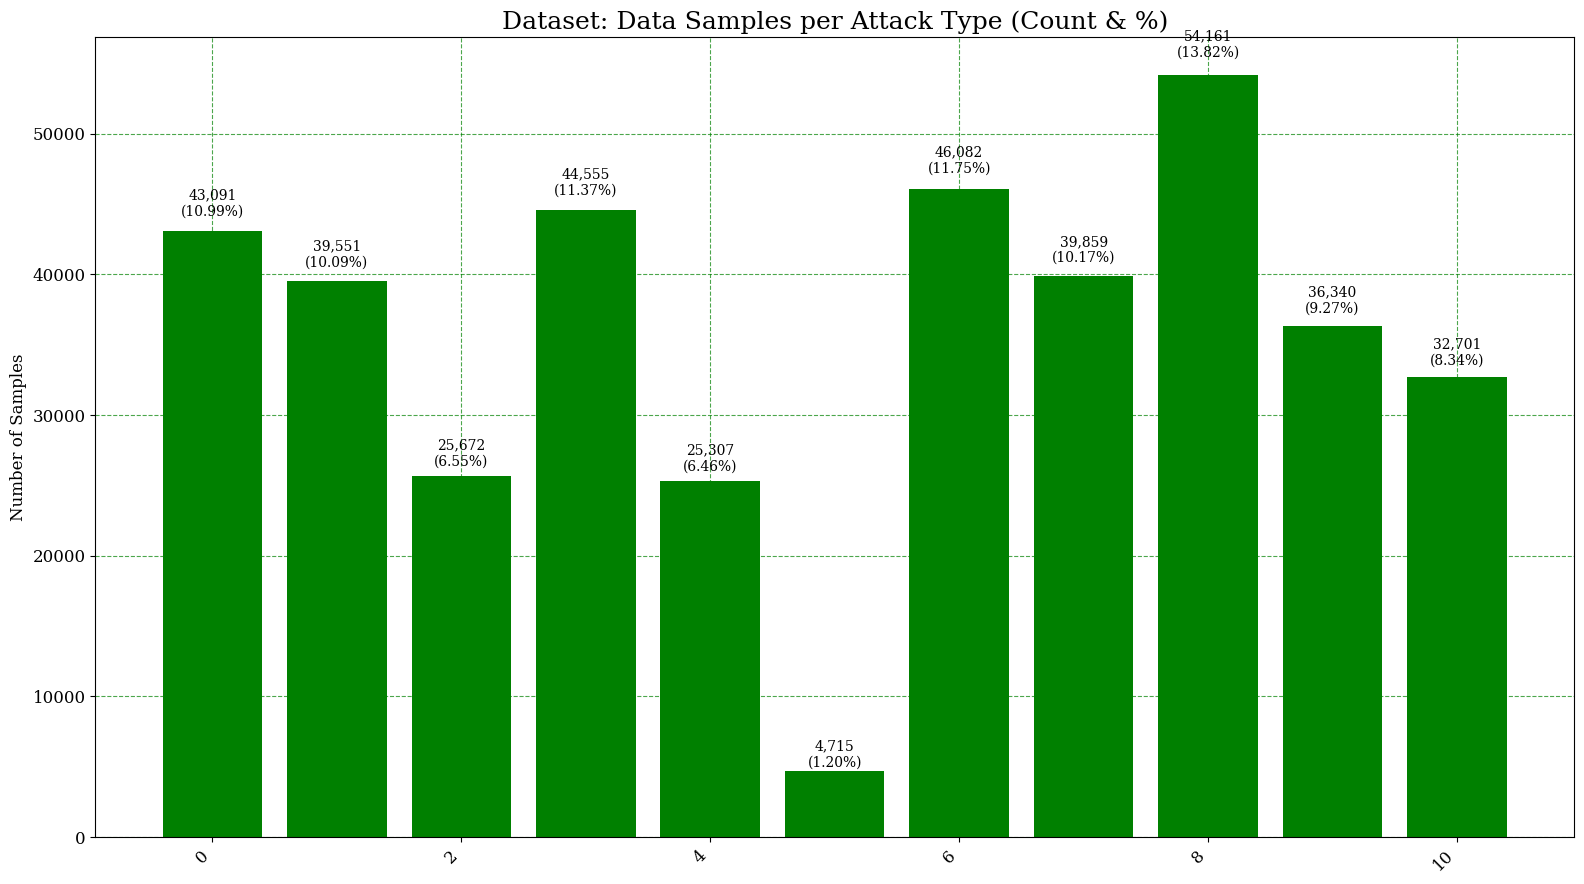

In [ ]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

if len(categorical_cols) > 0 and not df[categorical_cols].mode().empty:
    df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
else:
    print("Nothing to fill in categorical columns.")

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled



Columns with Missing Values:
 Series([], dtype: int64)
Nothing to fill in categorical columns.
Missing values after filling:
 0


In [ ]:
# Print the names of the features (columns)
print(df.columns)

Index(['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       

## **Data Preprocessing**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ১. ইনফিনিটি এবং গারবেজ ভ্যালু ক্লিন করা
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)
df.dropna(inplace=True)

# ২. Numerical কলাম আলাদা করা (Label বাদ দিয়ে)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])

# ৩. ফিচার স্কেলিং (শুধু Numerical ফিচারে)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# ৪. Categorical কলাম আলাদা করা (Label বাদ দিয়ে)
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# ৫. Categorical এনকোডিং (সব কলাম স্ট্রিং নিশ্চিত করে)
df[cat_cols] = df[cat_cols].astype(str)
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)



print("Preprocessing Success!")
print(df['Label'].value_counts()) # চেক করুন শুধু ০ এবং ১ আছে কি না


Preprocessing Success!
Label
8     54161
6     46082
3     44555
0     43091
7     39859
1     39551
9     36340
10    32701
2     25672
4     25307
5      4715
Name: count, dtype: int64


In [ ]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.222340,0.910006,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.298340,-0.228280,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.222340,1.213123,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,-0.384353,1.874255,-0.484792,-0.181792,-0.095267,-0.050322,-0.074195,-0.323785,0.583875,-0.097825,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392030,-0.379784,1.874255,-0.482212,-0.181792,-0.095267,-0.050322,-0.075569,-0.323785,0.583875,-0.097825,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392031,-0.384353,1.874255,-0.483113,-0.181792,-0.095267,-0.050863,-0.075114,-0.339507,0.432709,-0.166890,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392032,-0.384353,1.874255,-0.484786,-0.181792,-0.095267,-0.051044,-0.074613,-0.344747,0.382321,-0.189911,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10


## **After Processing**

In [ ]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


In [ ]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [ ]:
# বাইনারি ক্লাসিফিকেশনের জন্য লেবেল রূপান্তর (যদি ০ Benign হয়)
# এটি করলে আপনার ১১টি ক্লাস ০ এবং ১ এ চলে আসবে
df1['Label'] = df1['Label'].apply(lambda x: 0 if x == 0 else 1)

# Check counts
print(df1['Label'].value_counts())

# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

Label
1    348943
0     43091
Name: count, dtype: int64


In [ ]:
X.head()

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.22234,0.910006,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.22234,-0.377920,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.22234,-0.377920,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.29834,-0.228280,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.22234,1.213123,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464


## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.3,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y
)
# 3. 🔥 SMOTE
#from imblearn.over_sampling import SMOTE

#sm = SMOTE(random_state=42)
#X_train, y_train = sm.fit_resample(X_train, y_train)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (274423, 78)
X_test shape:  (117611, 78)
y_train shape: (274423,)
y_test shape:  (117611,)


Feature selection

In [ ]:

import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier # Changed from RandomForestClassifier

# ১. লেবেলগুলোকে অবশ্যই পূর্ণসংখ্যা (Integer) হতে হবে
# আপনার লেবেলে যদি -১.৫৪ টাইপ ভ্যালু থাকে, সেগুলোকে ০ এবং ১-এ বদলে নিন
#y_train_int = y_train.astype(int)

# ২. LightGBM মডেল (ইমব্যালেন্স ডাটা হ্যান্ডেল করার জন্য)
lgbm_selector = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42

)

# ৩. ট্রেইন করা
lgbm_selector.fit(X_train, y_train)

# ৪. এখন ইম্পর্ট্যান্স চেক করুন
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_selector.feature_importances_ # Using LGBM feature importances
}).sort_values(by='Importance', ascending=False)

# ৫. সেরা ৪০টি ফিচারের নাম নেওয়া
top_25_features = importance_df.head(10)['Feature'].tolist()

print("Top 10 Features (LightGBM) for Binary Classification:")
print(importance_df.head(10))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.288438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14114
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890082 -> initscore=2.091580
[LightGBM] [Info] Start training from score 2.091580
Top 10 Features (LightGBM) for Binary Classification:
                        Feature  Importance
67      Init_Win_bytes_backward        2218
66       Init_Win_bytes_forward        2127
20                 Flow IAT Min        1518
25                  Fwd IAT Min        1200
0              Destination Port        1101
2                 Flow Duration        1059
5   Total Length of Fwd Packets         997
19                 

/tmp/ipykernel_1215/1022900583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


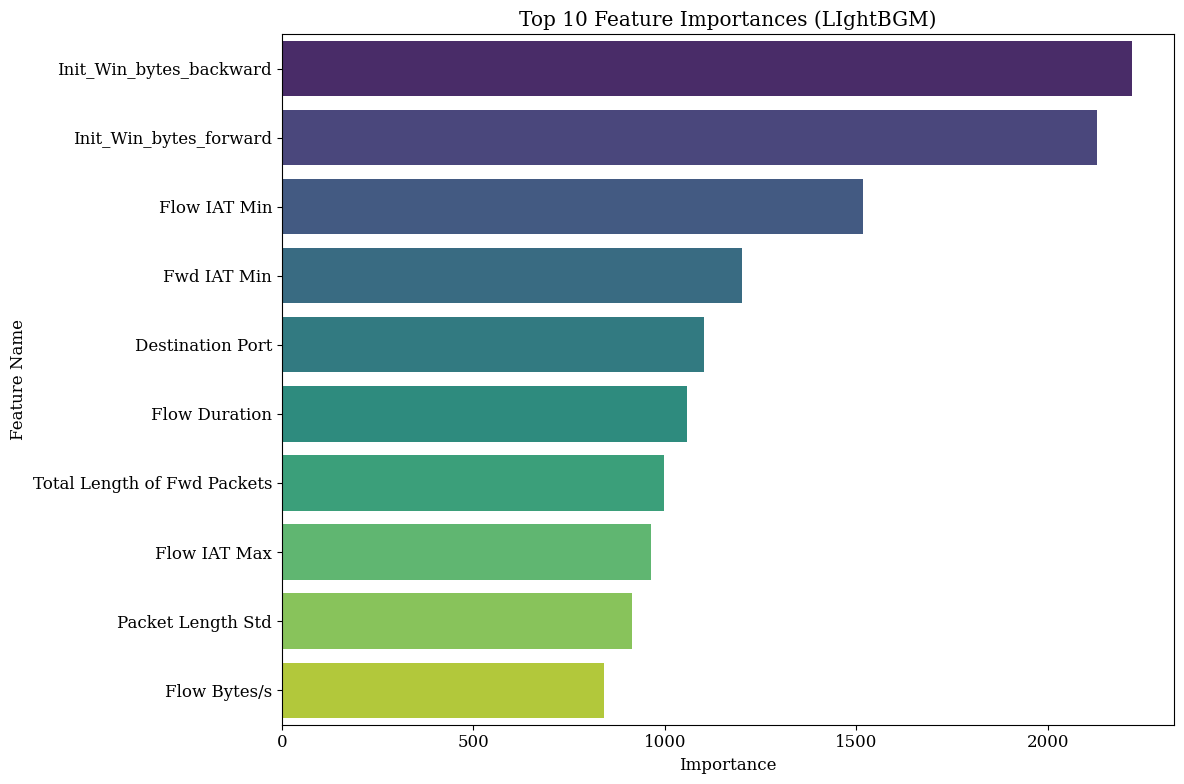

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (LIghtBGM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Autoencoder Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,618 (25.85 KB)

 Trainable params: 6,618 (25.85 KB)

 Non-trainable params: 0 (0.00 B)


Training Denoising Autoencoder...
Denoising Autoencoder training complete.


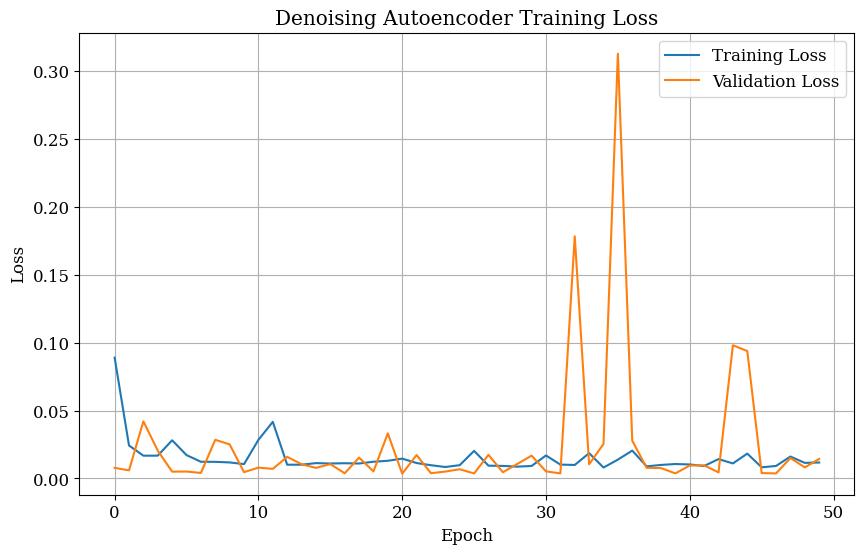

8576/8576 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 4s 989us/step

Original X_train_sel shape: (274423, 10)
New X_train_sel_ae shape (extracted features): (274423, 16)
Original X_test_sel shape: (117611, 10)
New X_test_sel_ae shape (extracted features): (117611, 16)

X_train_sel and X_test_sel have been updated with DAE extracted features.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

X_train_sel = X_train[top_25_features]
X_test_sel = X_test[top_25_features]

# Ensure X_train_sel and X_test_sel are available from previous steps
# They should already contain the features selected by LightGBM (top 10 features)

# Input dimension for the Autoencoder
input_dim = X_train_sel.shape[1]

# Define the Denoising Autoencoder model
# 1. Encoder
input_layer = Input(shape=(input_dim,))
# Add Gaussian Noise to the input
noisy_input = GaussianNoise(0.2)(input_layer) # Adjust noise_factor as needed

encoded = Dense(64, activation='relu')(noisy_input)
encoded = Dense(32, activation='relu')(encoded)

# 2. Latent space (bottleneck layer - this is what we'll use as new features)
latent_space = Dense(16, activation='relu', name='encoder_output')(encoded)

# 3. Decoder
decoded = Dense(32, activation='relu')(latent_space)
decoded = Dense(64, activation='relu')(decoded)

# Output layer (reconstructs the original input)
output_layer = Dense(input_dim, activation='linear')(decoded)

# Create the Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compile the Autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Display model summary
print("Autoencoder Model Summary:")
autoencoder.summary()

# Train the Autoencoder
# We train the autoencoder to reconstruct the original input from the noisy input
print("\nTraining Denoising Autoencoder...")
history = autoencoder.fit(
    X_train_sel, X_train_sel, # Input is also the target for reconstruction
    epochs=50,                # Number of training epochs
    batch_size=128,           # Batch size
    shuffle=True,             # Shuffle data for each epoch
    validation_split=0.2,     # Use 20% of training data for validation
    verbose=0                 # Suppress verbose output during training
)
print("Denoising Autoencoder training complete.")

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Denoising Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Extract the Encoder part of the Autoencoder (to get the latent space features)
encoder = Model(inputs=input_layer, outputs=autoencoder.get_layer('encoder_output').output)

# Transform the original datasets using the trained encoder
X_train_sel_ae = encoder.predict(X_train_sel)
X_test_sel_ae = encoder.predict(X_test_sel)

print(f"\nOriginal X_train_sel shape: {X_train_sel.shape}")
print(f"New X_train_sel_ae shape (extracted features): {X_train_sel_ae.shape}")
print(f"Original X_test_sel shape: {X_test_sel.shape}")
print(f"New X_test_sel_ae shape (extracted features): {X_test_sel_ae.shape}")

# Update X_train_sel and X_test_sel to use the new, extracted features
X_train_sel = X_train_sel_ae
X_test_sel = X_test_sel_ae

print("\nX_train_sel and X_test_sel have been updated with DAE extracted features.")

## **Train & Evaluate Extra Trees Classifier**

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Extra Trees Classifier
et_model = ExtraTreesClassifier(n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1) # Using parameters similar to Random Forest for a good starting point
et_model.fit(X_train_sel_ae, y_train)

# 2. Predict on Test Set
y_pred = et_model.predict(X_test_sel_ae)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=et_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Extra Trees - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

KeyboardInterrupt: 

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.8574
Precision: 0.8581
Recall:    0.8574
F1 Score:  0.8577


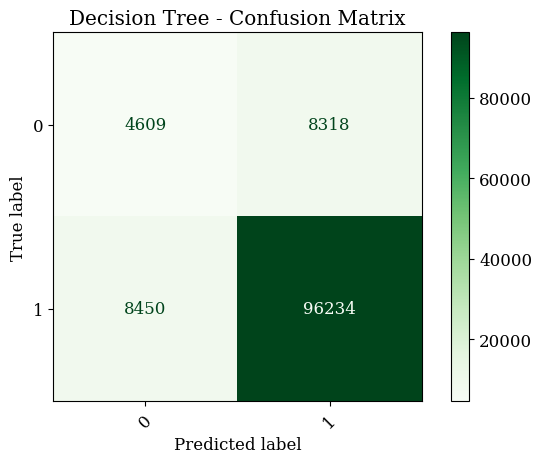

Classification Report:
              precision    recall  f1-score   support

           0    0.35294   0.35654   0.35473     12927
           1    0.92044   0.91928   0.91986    104684

    accuracy                        0.85743    117611
   macro avg    0.63669   0.63791   0.63730    117611
weighted avg    0.85807   0.85743   0.85775    117611



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
#X_train_sel = X_train[top_25_features]
#X_test_sel = X_test[top_25_features]


# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sel_ae, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_sel_ae)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.88691
Precision: 0.89154
Recall:    0.88691
F1 Score:  0.88908


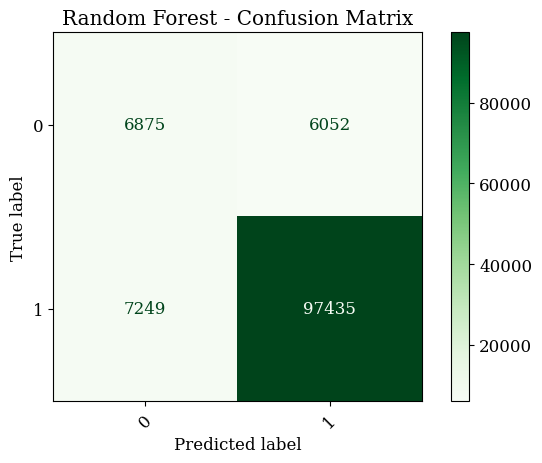

Classification Report:
              precision    recall  f1-score   support

           0    0.48676   0.53183   0.50830     12927
           1    0.94152   0.93075   0.93611    104684

    accuracy                        0.88691    117611
   macro avg    0.71414   0.73129   0.72220    117611
weighted avg    0.89154   0.88691   0.88908    117611



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.80588
Precision: 0.87123
Recall:    0.80588
F1 Score:  0.83075


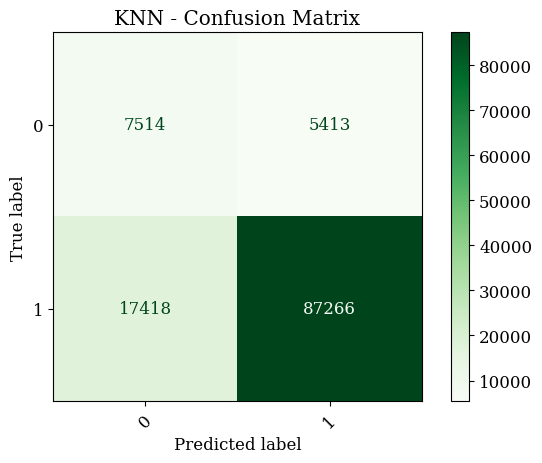

Classification Report:
              precision    recall  f1-score   support

           0    0.30138   0.58126   0.39695     12927
           1    0.94159   0.83361   0.88432    104684

    accuracy                        0.80588    117611
   macro avg    0.62149   0.70744   0.64063    117611
weighted avg    0.87123   0.80588   0.83075    117611



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=3)  # You can tune n_neighbors
knn_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Voting Classifier...
Voting Classifier training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Voting Classifier Accuracy:  0.89989
Voting Classifier Precision: 0.88028
Voting Classifier Recall:    0.89989
Voting Classifier F1 Score:  0.87378


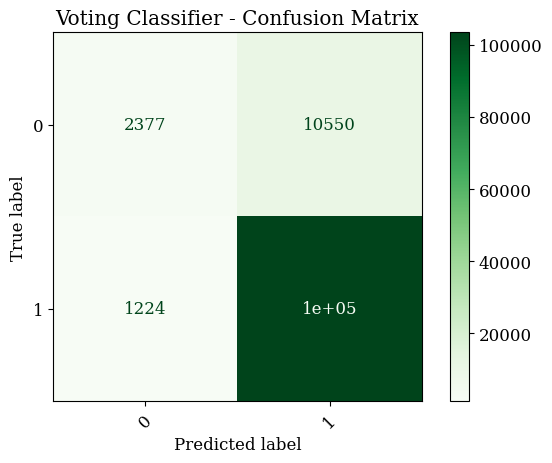

Voting Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.66009   0.18388   0.28763     12927
           1    0.90746   0.98831   0.94616    104684

    accuracy                        0.89989    117611
   macro avg    0.78378   0.58609   0.61690    117611
weighted avg    0.88028   0.89989   0.87378    117611



In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Import LightGBM and XGBoost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Re-initialize individual classifiers for the VotingClassifier
# (using the best parameters found in previous cells if applicable,
# or default parameters if not explicitly optimized)

# dt_model = DecisionTreeClassifier(random_state=42) # Removed as requested
rf_model = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
# knn_model = KNeighborsClassifier(n_neighbors=3) # Removed as requested

lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

# Define X_train_sel and X_test_sel from the top_25_features
#X_train_sel = X_train[top_25_features]
#X_test_sel = X_test[top_25_features]

# Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        # ('dt', dt_model),
        ('rf', rf_model),
        # ('knn', knn_model)
        ('lgbm', lgbm_model),
        ('xgb', xgb_model)
    ],
    voting='soft',  # 'hard' for majority vote, 'soft' for weighted average of probabilities
    n_jobs=-1
)

print("Training Voting Classifier...")
# Train the Voting Classifier
voting_clf.fit(X_train_sel_ae, y_train)
print("Voting Classifier training complete.")

# Predict on Test Set
y_pred_voting = voting_clf.predict(X_test_sel_ae)

# Evaluation Metrics
accuracy_voting = accuracy_score(y_test, y_pred_voting)
precision_voting = precision_score(y_test, y_pred_voting, average='weighted', zero_division=0)
recall_voting = recall_score(y_test, y_pred_voting, average='weighted', zero_division=0)
f1_voting = f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nVoting Classifier Accuracy:  {accuracy_voting:.5f}")
print(f"Voting Classifier Precision: {precision_voting:.5f}")
print(f"Voting Classifier Recall:    {recall_voting:.5f}")
print(f"Voting Classifier F1 Score:  {f1_voting:.5f}")

# Confusion Matrix
cm_voting = confusion_matrix(y_test, y_pred_voting)
ConfusionMatrixDisplay(cm_voting, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting, zero_division=0, digits=5))


## **ভোটিং ক্লাসিফায়ার টিউনিং (Tuning Voting Classifier)**

ভোটিং ক্লাসিফায়ারের নিজস্ব হাইপারপ্যারামিটারগুলো টিউন করতে, যেমন `voting` পদ্ধতি ('soft' বা 'hard') এবং প্রতিটি বেস মডেলের `weights`, আমরা `GridSearchCV` ব্যবহার করতে পারি। এটি প্রতিটি বেস মডেলের অবদানকে অপ্টিমাইজ করতে সাহায্য করবে।

**গুরুত্বপূর্ণ:** এই টিউনিং চালানোর আগে, নিশ্চিত করুন যে আপনার বেস মডেলগুলো (`rf_model`, `lgbm_model`, `xgb_model`) পূর্ববর্তী সেলে (Cell ID: `I7f0jL92Pls8`) ইনিশিয়ালাইজ করা হয়েছে।

Starting Hyperparameter Tuning for VotingClassifier...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

VotingClassifier Best Parameters found: {'voting': 'soft', 'weights': [2, 1, 1]}
VotingClassifier Best F1-weighted score: 0.8725679011978323
VotingClassifier tuning complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Tuned Voting Classifier Accuracy:  0.89878
Tuned Voting Classifier Precision: 0.87762
Tuned Voting Classifier Recall:    0.89878
Tuned Voting Classifier F1 Score:  0.87691


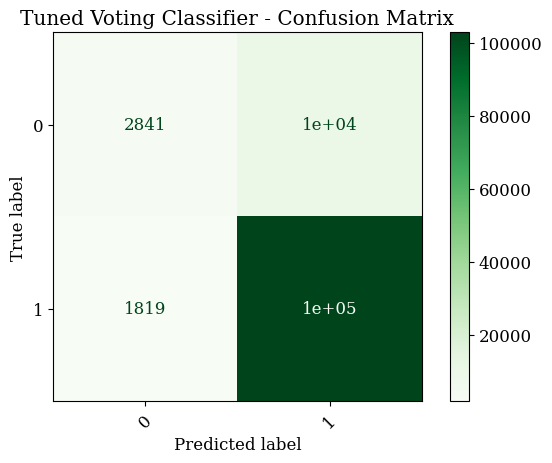

Tuned Voting Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.60966   0.21977   0.32308     12927
           1    0.91070   0.98262   0.94530    104684

    accuracy                        0.89878    117611
   macro avg    0.76018   0.60120   0.63419    117611
weighted avg    0.87762   0.89878   0.87691    117611



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("Starting Hyperparameter Tuning for VotingClassifier...")

# বেস মডেলগুলোকে আবারও সংজ্ঞায়িত করা হচ্ছে যদি এই সেলটি আলাদাভাবে চালানো হয়।
# যদি আগের সেল (I7f0jL92Pls8) চালানো হয়ে থাকে, তাহলে এই মডেলগুলো ইতিমধ্যে সংজ্ঞায়িত।
# এখানে আমরা আগের সেলের মডেল ইনস্ট্যান্স ব্যবহার করব।

# If you run this cell independently, ensure rf_model, lgbm_model, xgb_model are defined.
# For continuity, we assume they are defined from cell I7f0jL92Pls8.
# dt_model = DecisionTreeClassifier(random_state=42) # Removed as requested
# knn_model = KNeighborsClassifier(n_neighbors=3) # Removed as requested

# Ensure these are the models you want to include in the VotingClassifier for tuning
# For this example, we'll use the already defined rf_model, lgbm_model, xgb_model.
# If you want to use the *tuned* versions from previous steps, replace them here.

# Redefine the individual classifiers here to ensure they are available
rf_model = RandomForestClassifier(n_estimators=50, max_depth=None, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
lgbm_model = LGBMClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=50, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

estinators = [
    ('rf', rf_model), # Using rf_model from cell I7f0jL92Pls8
    ('lgbm', lgbm_model), # Using lgbm_model from cell I7f0jL92Pls8
    ('xgb', xgb_model) # Using xgb_model from cell I7f0jL92Pls8
]

# ভোটিং ক্লাসিফায়ারের জন্য প্যারামিটার গ্রিড সেট করুন
# weights এর জন্য বিভিন্ন কম্বিনেশন তৈরি করা দরকার।
# এখানে একটি সহজ গ্রিড দেখানো হলো। আপনার প্রয়োজন অনুযায়ী এটি আরও বাড়াতে পারেন।
param_grid_voting = {
    'voting': ['soft'], # অথবা ['hard', 'soft'] যদি hard voting ও পরীক্ষা করতে চান
    'weights': [
        [1, 1, 1], # সমান ওজন
        [2, 1, 1], # RandomForest কে বেশি ওজন
        [1, 2, 1], # LightGBM কে বেশি ওজন
        [1, 1, 2]  # XGBoost কে বেশি ওজন
        # আরও কম্বিনেশন যোগ করুন যেমন [0.5, 0.3, 0.2] ইত্যাদি
    ]
}

# ভোটিং ক্লাসিফায়ার ইনিশিয়ালাইজ করুন
voting_clf_tune = VotingClassifier(estimators=estinators, n_jobs=-1)

# GridSearchCV সেটআপ করুন
grid_search_voting = GridSearchCV(
    estimator=voting_clf_tune,
    param_grid=param_grid_voting,
    cv=3, # ক্রস-ভ্যালিডেশন ফোল্ডের সংখ্যা
    scoring='f1_weighted', # আপনার মূল্যায়নের মেট্রিক
    n_jobs=-1, # সব কোর ব্যবহার করুন
    verbose=1 # প্রোগ্রেস দেখতে
)

# গ্রিড সার্চ ট্রেইন করুন
grid_search_voting.fit(X_train_sel_ae, y_train)

# সেরা প্যারামিটার এবং স্কোর প্রিন্ট করুন
print("\nVotingClassifier Best Parameters found:", grid_search_voting.best_params_)
print("VotingClassifier Best F1-weighted score:", grid_search_voting.best_score_)

# সেরা মডেলটি নিন
tuned_voting_clf = grid_search_voting.best_estimator_

print("VotingClassifier tuning complete.")

# এখন এই tuned_voting_clf ব্যবহার করে ভবিষ্যদ্বাণী এবং মূল্যায়ন করতে পারেন

# Predict on Test Set with tuned Voting Classifier
y_pred_tuned_voting = tuned_voting_clf.predict(X_test_sel_ae)

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy_tuned_voting = accuracy_score(y_test, y_pred_tuned_voting)
precision_tuned_voting = precision_score(y_test, y_pred_tuned_voting, average='weighted', zero_division=0)
recall_tuned_voting = recall_score(y_test, y_pred_tuned_voting, average='weighted', zero_division=0)
f1_tuned_voting = f1_score(y_test, y_pred_tuned_voting, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nTuned Voting Classifier Accuracy:  {accuracy_tuned_voting:.5f}")
print(f"Tuned Voting Classifier Precision: {precision_tuned_voting:.5f}")
print(f"Tuned Voting Classifier Recall:    {recall_tuned_voting:.5f}")
print(f"Tuned Voting Classifier F1 Score:  {f1_tuned_voting:.5f}")

# Confusion Matrix
cm_tuned_voting = confusion_matrix(y_test, y_pred_tuned_voting)
ConfusionMatrixDisplay(cm_tuned_voting, display_labels=tuned_voting_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Tuned Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Tuned Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_tuned_voting, zero_division=0, digits=5))

## **স্টেপ-বাই-স্টেপ অপটিমাইজেশন প্ল্যান:**

1.  **প্রতিটি বেস মডেলের হাইপারপ্যারামিটার টিউনিং:** `GridSearchCV` ব্যবহার করে `RandomForestClassifier`, `LGBMClassifier` এবং `XGBClassifier`-এর সর্বোত্তম হাইপারপ্যারামিটারগুলি খুঁজে বের করা হবে।
2.  **অপটিমাইজড মডেলগুলি সহ ভোটিং ক্লাসিফায়ার টিউনিং:** পূর্ববর্তী ধাপে প্রাপ্ত সেরা মডেলগুলি ব্যবহার করে `VotingClassifier` তৈরি করা হবে এবং `weights` প্যারামিটারের জন্য একটি বিস্তৃত অনুসন্ধান চালানো হবে।

### **১. RandomForestClassifier টিউনিং**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Tuning RandomForestClassifier...")

# RandomForestClassifier এর জন্য প্যারামিটার গ্রিড
param_grid_rf = {
    'n_estimators': [50, 100], # কম থেকে শুরু করুন, প্রয়োজনে বাড়ান
    'max_depth': [10, 20], # Reduced max_depth for faster training
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train_sel_ae, y_train)

best_rf_model = rf_grid_search.best_estimator_

print("RandomForestClassifier Best Parameters:", rf_grid_search.best_params_)
print("RandomForestClassifier Best F1-weighted score:", rf_grid_search.best_score_)
print("RandomForestClassifier tuning complete.")

Tuning RandomForestClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
RandomForestClassifier Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RandomForestClassifier Best F1-weighted score: 0.8268640845408028
RandomForestClassifier tuning complete.


### **২. LGBMClassifier টিউনিং**

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

print("Tuning LGBMClassifier...")

# LGBMClassifier এর জন্য প্যারামিটার গ্রিড
param_grid_lgbm = {
    'n_estimators': [50, 100], # Reduced n_estimators for faster training
    'num_leaves': [31, 64],
    'max_depth': [10, -1],
    'learning_rate': [0.05, 0.1],
    'class_weight': ['balanced']
}

lgbm_grid_search = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, feature_name='auto'), # Added feature_name='auto'
    param_grid=param_grid_lgbm,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

lgbm_grid_search.fit(X_train_sel_ae, y_train)

best_lgbm_model = lgbm_grid_search.best_estimator_

print("LGBMClassifier Best Parameters:", lgbm_grid_search.best_params_)
print("LGBMClassifier Best F1-weighted score:", lgbm_grid_search.best_score_)
print("LGBMClassifier tuning complete.")

Tuning LGBMClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LGBMClassifier Best Parameters: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 64}
LGBMClassifier Best F1-weighted score: 0.6884636033024657
LGBMClassifier tuning complete.


### **৩. XGBClassifier টিউনিং**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

print("Tuning XGBClassifier...")

# XGBClassifier এর জন্য প্যারামিটার গ্রিড
param_grid_xgb = {
    'n_estimators': [50, 100], # Reduced n_estimators for faster training
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'use_label_encoder': [False], # Deprecation warning এড়াতে
    'eval_metric': ['mlogloss'] # Multiclassification এর জন্য
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_sel_ae, y_train)

best_xgb_model = xgb_grid_search.best_estimator_

print("XGBClassifier Best Parameters:", xgb_grid_search.best_params_)
print("XGBClassifier Best F1-weighted score:", xgb_grid_search.best_score_)
print("XGBClassifier tuning complete.")

Tuning XGBClassifier...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:31:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier Best Parameters: {'colsample_bytree': 1.0, 'eval_metric': 'mlogloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8, 'use_label_encoder': False}
XGBClassifier Best F1-weighted score: 0.8422869955796286
XGBClassifier tuning complete.


### **৪. অপটিমাইজড বেস মডেলগুলি সহ ভোটিং ক্লাসিফায়ার টিউনিং**

এবার, আমরা পূর্ববর্তী ধাপে টিউন করা সেরা মডেলগুলি ব্যবহার করে `VotingClassifier`-কে আরও বিস্তৃত `weights` কম্বিনেশনের সাথে টিউন করব।

Starting VotingClassifier tuning with optimized base models and extended weights...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Final Tuned VotingClassifier Best Parameters found: {'voting': 'soft', 'weights': [2, 1, 1]}
Final Tuned VotingClassifier Best F1-weighted score: 0.8685810954058167
Final VotingClassifier tuning complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Final Tuned Voting Classifier Accuracy:  0.88871
Final Tuned Voting Classifier Precision: 0.86403
Final Tuned Voting Classifier Recall:    0.88871
Final Tuned Voting Classifier F1 Score:  0.87043


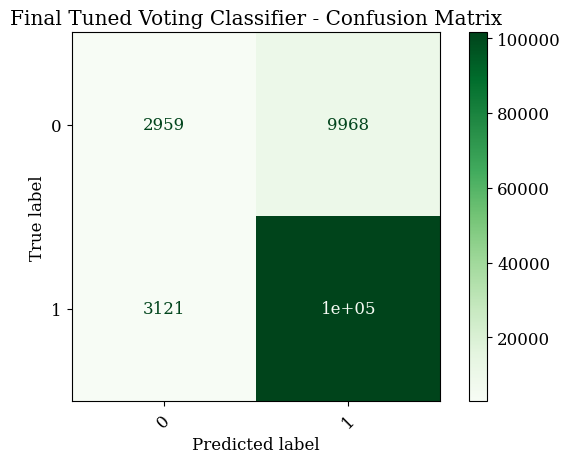

Final Tuned Voting Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.48668   0.22890   0.31136     12927
           1    0.91063   0.97019   0.93946    104684

    accuracy                        0.88871    117611
   macro avg    0.69865   0.59954   0.62541    117611
weighted avg    0.86403   0.88871   0.87043    117611



In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Starting VotingClassifier tuning with optimized base models and extended weights...")

estimators_optimized = [
    ('rf', best_rf_model),
    ('lgbm', best_lgbm_model),
    ('xgb', best_xgb_model)
]

# `weights` এর জন্য আরও বিস্তৃত প্যারামিটার গ্রিড
param_grid_voting_final = {
    'voting': ['soft'],
    'weights': [
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2]
    ]
}

voting_clf_final = VotingClassifier(estimators=estimators_optimized, n_jobs=-1)

grid_search_voting_final = GridSearchCV(
    estimator=voting_clf_final,
    param_grid=param_grid_voting_final,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_voting_final.fit(X_train_sel_ae, y_train)

tuned_voting_clf_final = grid_search_voting_final.best_estimator_

print("\nFinal Tuned VotingClassifier Best Parameters found:", grid_search_voting_final.best_params_)
print("Final Tuned VotingClassifier Best F1-weighted score:", grid_search_voting_final.best_score_)
print("Final VotingClassifier tuning complete.")

# Evaluate the final tuned Voting Classifier
y_pred_tuned_voting_final = tuned_voting_clf_final.predict(X_test_sel_ae)

accuracy_tuned_voting_final = accuracy_score(y_test, y_pred_tuned_voting_final)
precision_tuned_voting_final = precision_score(y_test, y_pred_tuned_voting_final, average='weighted', zero_division=0)
recall_tuned_voting_final = recall_score(y_test, y_pred_tuned_voting_final, average='weighted', zero_division=0)
f1_tuned_voting_final = f1_score(y_test, y_pred_tuned_voting_final, average='weighted', zero_division=0)

print(f"\nFinal Tuned Voting Classifier Accuracy:  {accuracy_tuned_voting_final:.5f}")
print(f"Final Tuned Voting Classifier Precision: {precision_tuned_voting_final:.5f}")
print(f"Final Tuned Voting Classifier Recall:    {recall_tuned_voting_final:.5f}")
print(f"Final Tuned Voting Classifier F1 Score:  {f1_tuned_voting_final:.5f}")

cm_tuned_voting_final = confusion_matrix(y_test, y_pred_tuned_voting_final)
ConfusionMatrixDisplay(cm_tuned_voting_final, display_labels=tuned_voting_clf_final.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Final Tuned Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

print("Final Tuned Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_tuned_voting_final, zero_division=0, digits=5))

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("Starting Cross-Validation for Binary Classification...")

# Initialize StratifiedKFold for cross-validation
# n_splits determines the number of folds
# shuffle=True shuffles the data before splitting into batches
# random_state ensures reproducibility
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterate over each fold
for fold, (train_index, val_index) in enumerate(stratified_kfold.split(X_train_sel_ae, y_train)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # Split data for the current fold
    X_train_fold, X_val_fold = X_train_sel_ae[train_index], X_train_sel_ae[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the tuned Voting Classifier on the current fold's training data
    # Make sure 'tuned_voting_clf_final' is defined from the previous tuning step
    tuned_voting_clf_final.fit(X_train_fold, y_train_fold)

    # Make predictions on the current fold's validation data
    y_pred_fold = tuned_voting_clf_final.predict(X_val_fold)

    # Calculate metrics for the current fold
    accuracy = accuracy_score(y_val_fold, y_pred_fold)
    precision = precision_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
    recall = recall_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
    f1 = f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"Accuracy:  {accuracy:.5f}")
    print(f"Precision: {precision:.5f}")
    print(f"Recall:    {recall:.5f}")
    print(f"F1 Score:  {f1:.5f}")

# Calculate and print average metrics across all folds
print("\n--- Average Cross-Validation Results ---")
print(f"Average Accuracy:  {np.mean(accuracy_scores):.5f} (+/- {np.std(accuracy_scores):.5f})")
print(f"Average Precision: {np.mean(precision_scores):.5f} (+/- {np.std(precision_scores):.5f})")
print(f"Average Recall:    {np.mean(recall_scores):.5f} (+/- {np.std(recall_scores):.5f})")
print(f"Average F1 Score:  {np.mean(f1_scores):.5f} (+/- {np.std(f1_scores):.5f})")

print("Cross-Validation complete.")

Starting Cross-Validation for Binary Classification...

--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy:  0.88899
Precision: 0.86279
Recall:    0.88899
F1 Score:  0.86892

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy:  0.88984
Precision: 0.86376
Recall:    0.88984
F1 Score:  0.86943

--- Fold 3/5 ---


...

Accuracy:  0.88868
Precision: 0.86268
Recall:    0.88868
F1 Score:  0.86898

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy:  0.88826
Precision: 0.86219
Recall:    0.88826
F1 Score:  0.86869

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy:  0.88773
Precision: 0.86257
Recall:    0.88773
F1 Score:  0.86933

--- Average Cross-Validation Results ---
Average Accuracy:  0.88870 (+/- 0.00071)
Average Precision: 0.86280 (+/- 0.00052)
Average Recall:    0.88870 (+/- 0.00071)
Average F1 Score:  0.86907 (+/- 0.00027)
Cross-Validation complete.


# **Multiclass Classification**

In [ ]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 78)
X_test shape:  (78407, 78)
y_train shape: (313627,)
y_test shape:  (78407,)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.432758 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14117
[LightGBM] [Info] Number of data points in the train set: 313627, number of used features: 66
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
Top 10 Features for Multiclassifica

/tmp/ipykernel_36570/1523890530.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_multi.head(10), palette='viridis')


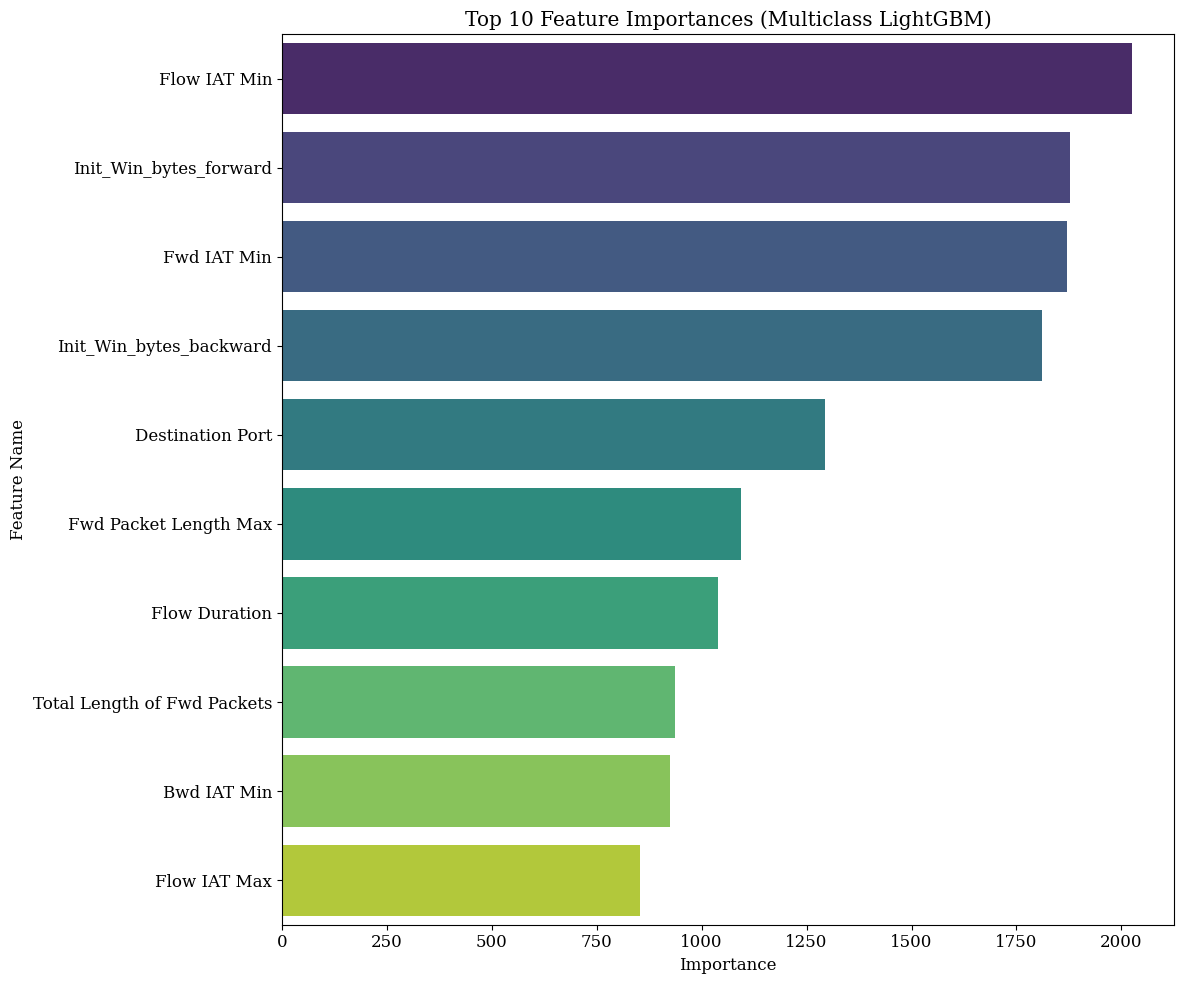

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier # Changed from RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LightGBM model for feature importance (changed from Random Forest)
lgbm_selector_multi = LGBMClassifier(
    n_estimators=100, # Number of boosting rounds
    random_state=42,  # For reproducibility
    class_weight='balanced' # Handles imbalanced classes, important for multiclass
)

# 2. Train the model on the multiclass training data
lgbm_selector_multi.fit(X_train, y_train)

# 3. Get feature importances
importance_df_multi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_selector_multi.feature_importances_ # Using LGBM feature importances
}).sort_values(by='Importance', ascending=False)

# 4. Select the top 10 features (adjust as needed)
top_10_features_multi = importance_df_multi.head(10)['Feature'].tolist()

print("Top 10 Features for Multiclassification (LightGBM):")
print(importance_df_multi.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df_multi.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Multiclass LightGBM)') # Updated title
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

X_train_sel_multi = X_train[top_10_features_multi]
X_test_sel_multi = X_test[top_10_features_multi]

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.3031
Precision: 0.3032
Recall:    0.3031
F1 Score:  0.3031


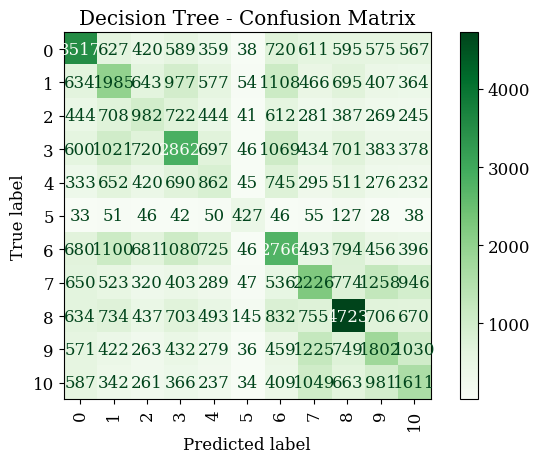

Classification Report:
              precision    recall  f1-score   support

           0    0.40504   0.40810   0.40657      8618
           1    0.24311   0.25095   0.24697      7910
           2    0.18910   0.19124   0.19016      5135
           3    0.32281   0.32118   0.32199      8911
           4    0.17199   0.17032   0.17115      5061
           5    0.44526   0.45281   0.44900       943
           6    0.29736   0.30010   0.29872      9217
           7    0.28213   0.27923   0.28067      7972
           8    0.44062   0.43602   0.43831     10832
           9    0.25235   0.24794   0.25012      7268
          10    0.24873   0.24633   0.24752      6540

    accuracy                        0.30307     78407
   macro avg    0.29986   0.30038   0.30011     78407
weighted avg    0.30322   0.30307   0.30313     78407



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sel_multi, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_sel_multi)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Voting

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Import LightGBM and XGBoost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Re-initialize individual classifiers for the VotingClassifier
# Using parameters from previously trained models or sensible defaults

# Removed Decision Tree and KNN, added LightGBM and XGBoost
# dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Adjust n_estimators as needed
# knn_model = KNeighborsClassifier(n_neighbors=5) # Using n_neighbors=5 as in previous KNN multiclassification

lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

# Create the Voting Classifier
voting_clf_multi = VotingClassifier(
    estimators=[
        # ('dt', dt_model),
        ('rf', rf_model),
        # ('knn', knn_model)
        ('lgbm', lgbm_model),
        ('xgb', xgb_model)
    ],
    voting='soft',  # 'soft' for weighted average of probabilities (if supported by base estimators)
    n_jobs=-1
    # Weights can be adjusted based on individual model performance
    # weights=[1, 1, 1] # Example weights if you want to assign them
)

print("Training Multiclass Voting Classifier...")
# Train the Voting Classifier on the selected features
voting_clf_multi.fit(X_train_sel_multi, y_train)
print("Multiclass Voting Classifier training complete.")

# Predict on Test Set using selected features
y_pred_voting_multi = voting_clf_multi.predict(X_test_sel_multi)

# Evaluation Metrics
accuracy_voting_multi = accuracy_score(y_test, y_pred_voting_multi)
precision_voting_multi = precision_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)
recall_voting_multi = recall_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)
f1_voting_multi = f1_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nMulticlass Voting Classifier Accuracy:  {accuracy_voting_multi:.5f}")
print(f"Multiclass Voting Classifier Precision: {precision_voting_multi:.5f}")
print(f"Multiclass Voting Classifier Recall:    {recall_voting_multi:.5f}")
print(f"Multiclass Voting Classifier F1 Score:  {f1_voting_multi:.5f}")

# Confusion Matrix
cm_voting_multi = confusion_matrix(y_test, y_pred_voting_multi)
ConfusionMatrixDisplay(cm_voting_multi, display_labels=voting_clf_multi.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Multiclass Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Multiclass Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting_multi, zero_division=0, digits=5))


## **Train & Evaluate Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 10, random_state=42)
rf_model.fit(X_train_sel_multi, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test_sel_multi)
y_proba = rf_model.predict_proba(X_test_sel_multi) # Corrected X_test_mul to X_test_sel_multi

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train_sel_multi, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_sel_multi)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**